# TESLA 9-Cell Cavity Chain

A worked study on a real accelerating structure: a chain of **three TESLA 9-cell cavities**,
solved with state-space concatenation.

```
Import CAD  ->  Chain x3  ->  FOM (one cavity)  ->  POD  ->  Concatenate  ->  Sweep + Fields
```

## Why this case is interesting

The three cavities are *identical*, so the full-order problem is solved **once** and the reduced
model is reused for every instance. Only the reduced matrices are concatenated, which is what
makes a wideband sweep of the whole chain take a fraction of a second.

Two things are worth watching:

1. **The accelerating passband.** Each 9-cell cavity has its accelerating modes just below
   $1.3$ GHz. Chaining three identical cavities gives every cavity mode a near-degenerate
   **triplet** -- one per cavity -- which is the fingerprint of the coupled chain.
2. **Field reconstruction.** The coupled solve happens in a reduced space of order 100 DOFs, yet
   the solution maps back onto each cavity's own mesh for 3D inspection, with no export to an
   external post-processor.


## 1. Import the cavity

The 9-cell geometry ships with the documentation as a STEP file. The importer detects the two
beam-pipe faces and assigns them as ports.

In [1]:
from cavsim3d.core.em_project import EMProject
import matplotlib.pyplot as plt
import numpy as np
import time
%matplotlib widget

proj = EMProject(name='tesla_chain', base_dir='./simulations', overwrite=True)
proj.main_axis = 'X'   # the TESLA CAD has its beam axis along x

# One cavity, used three times: n=3 chains three copies along the main axis.
cavity = proj.import_geometry('../example_models/tesla9cell.step', name='cavity',
                              unit='m', n=3)
# 3D view -- uncomment to open it when you run the notebook:
# cavity.show('geometry')

✅ Creating new project 'tesla_chain' at simulations\tesla_chain



STEP solids found:
  - 



Solid: ''
Ports by position along X: port1, port2


## 2. Build the chain

`n=3` repeats the cavity three times along the beam axis. The component is **computed once** and
referenced three times -- that is the point of the netlist form.

In [2]:
# the project's geometry is now the chain of three copies
print(proj.geometry.describe_layout())
print(f'single-cavity mesh: {cavity.mesh.ne} elements')

Main axis: X. Parts follow the list order along +X:
  1. cavity x3: x = [-0.7487, 0.7487] m
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; repeated: cavity (n=3))
single-cavity mesh: 61085 elements


## 3. Full-order solve on the single unique cavity

This is the only expensive step, and it runs on **one** cavity regardless of chain length.

!!! warning "Runtime, memory and snapshot placement"
    Expect several minutes and about **10 GB of RAM**: the 9-cell mesh carries roughly 630k
    DOFs and the direct solver factorises it at each frequency. Two further settings
    matter and neither is free to loosen:

    * The mesh is driven by the curvature of the cells and irises, so raising `maxh` does not
      make it cheaper, and coarsening the curvature resolution removes the accelerating
      passband altogether.
    * The snapshots are placed over $1.0-1.8$ GHz rather than from DC. Spreading the same twelve
      snapshots over $0-2$ GHz spends most of them near DC and the reduced model then misses
      the accelerating modes entirely.

In [3]:
fom_config = {
    'nportmodes': 2,
    'order': 2,
    'nsamples': 12,
    'fmin': 1.0,     # concentrate the snapshots on the accelerating band
    'fmax': 1.8,
    'solver_type': 'direct',
    'store_snapshots': True,   # required for POD
    'rerun': True,
}

t0 = time.time()
proj.fds.solve(config=fom_config)
t_fom = time.time() - t0
print(f'full-order solve (ONE cavity): {t_fom:.1f} s')

✅ Mesh strategy: coupled (repeated: cavity (n=3)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  cavity  geometry             compute   full-order solve, 12 samples



Structure Topology
  Type: Single structure
  Domains (1): ['']
  Ports (2): ['port1', 'port2']
  Mesh elements: 61085
✅ Section 'cavity': full-order solve


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=47.2077, sigma=+1
	port1 mode 1: TE_11 (sin), kc=47.2077, sigma=+1


	port2 mode 0: TE_11 (cos), kc=47.2068, sigma=+1
	port2 mode 1: TE_11 (sin), kc=47.2068, sigma=+1
Port eigenmodes complete: 4 total modes



FDS Solve: 1.0000 - 1.8000 GHz, 12 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 132.81s


✅ Netlist FOM stage complete: 1 unique section(s) for 3 instance(s)


full-order solve (ONE cavity): 139.6 s


## 4. Reduce

POD compresses the cavity to a handful of degrees of freedom.

In [4]:
t0 = time.time()
roms = proj.fds.foms.reduce(tol=1e-9)
t_rom = time.time() - t0
print(f'POD reduction: {t_rom:.1f} s')

Model Order Reduction


Reduction complete: 420116 -> 46 DOFs (100.0% compression)


POD reduction: 5.0 s


## 5. Concatenate and sweep the chain

`concatenate()` couples the reduced cavities at their shared beam-pipe interfaces. The resulting
system is small enough that a fine sweep is effectively free.

In [5]:
concat = roms.concatenate()
print(f'coupled system: {concat.coupled_dofs} DOFs')

t0 = time.time()
concat.solve(fmin=fom_config['fmin'], fmax=fom_config['fmax'], nsamples=800)
t_sweep = time.time() - t0
print(f'chain sweep, 800 points: {t_sweep*1e3:.0f} ms')
print(f'ratio to the full-order solve: {t_fom/t_sweep:,.0f}x')

coupled system: 134 DOFs

Concat Solve: 1.0 - 1.8 GHz, 800 samples, system size 134


  Concat solve complete: 0.276s (800 frequencies)


chain sweep, 800 points: 461 ms
ratio to the full-order solve: 303x


## 6. S-parameters of the chain

Text(0.5, 0.98, 'TESLA 3-cavity chain - S-parameters')

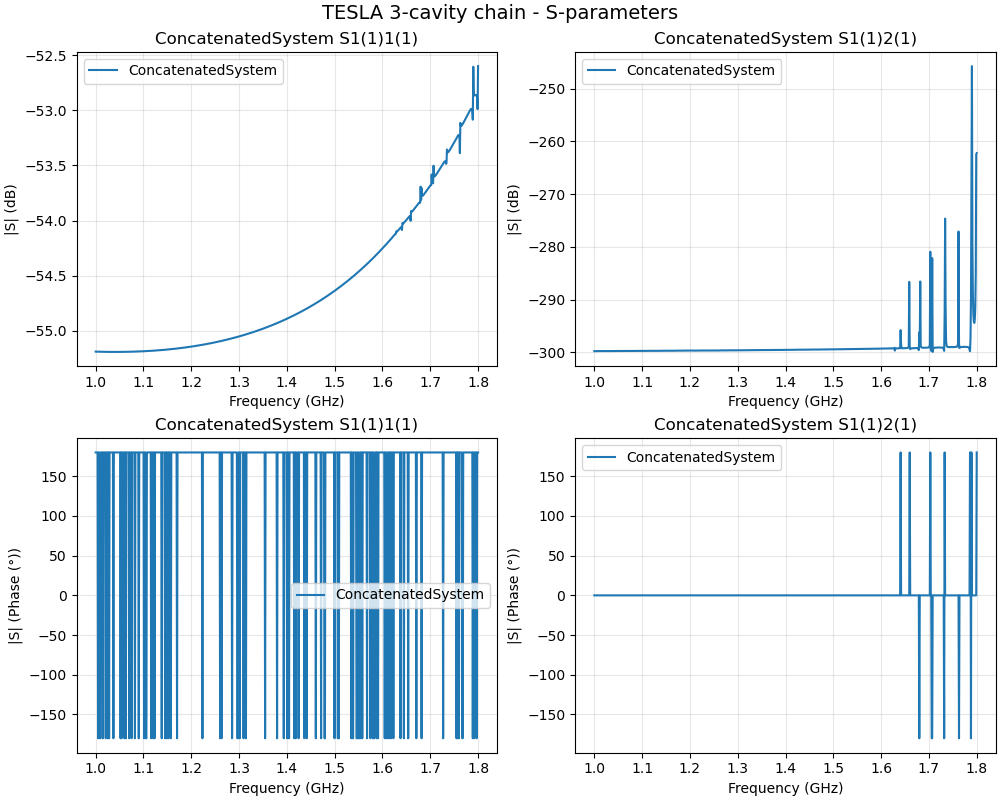

In [6]:
which = [['1(1)1(1)'], ['1(1)2(1)']]

fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    concat.plot_s(wh, ax=axs[idx + 1])
    concat.plot_s(wh, plot_type='phase', ax=axs[idx + 3])
fig.suptitle('TESLA 3-cavity chain - S-parameters', fontsize=14)

!!! note "Why the chain looks reflective"
    The beam pipe has a TE$_{11}$ cutoff near $2.25$ GHz, so across this sweep the ports are
    **below cutoff** and evanescent. That is correct for a TESLA cavity: the accelerating modes
    are trapped, which is what makes them useful. Those trapped modes are found through the
    eigenvalues below rather than through the S-parameters.

## 7. Chain eigenfrequencies

The eigenvalues of the coupled system are the resonances of the whole chain. `print_eigenfrequencies`
reports them per section and for the coupled (`global`) system; the `global` list is the one that
describes the chain.

Look for repeated values: three identical cavities give each mode a three-fold near-degenerate
triplet, so the count of modes in the accelerating band comes out as a multiple of three.

In [7]:
concat.print_eigenfrequencies(n_modes=16)

evals = np.asarray(concat.get_eigenvalues_filtered(filter_static=True, n_modes=80))
f_res = np.sqrt(np.abs(evals)) / (2 * np.pi) / 1e9      # GHz

passband = f_res[(f_res > 1.0) & (f_res < 1.6)]
print(f'\nmodes in the 1.0-1.6 GHz accelerating band: {len(passband)}')
print(np.array2string(passband, precision=4))


Eigenfrequencies

Domain: cavity_1
Index    Frequency (GHz)    ω² (rad²/s²)        


--------------------------------------------------
0        1.290237           6.5720e+19          
1        1.293255           6.6028e+19          
2        1.619201           1.0351e+20          
3        1.621101           1.0375e+20          
4        1.628213           1.0466e+20          
5        1.628513           1.0470e+20          
6        1.640935           1.0630e+20          
7        1.641410           1.0636e+20          
8        1.659053           1.0866e+20          
9        1.659139           1.0867e+20          
10       1.679748           1.1139e+20          
11       1.681682           1.1165e+20          
12       1.702752           1.1446e+20          
13       1.706682           1.1499e+20          
14       1.733486           1.1863e+20          
15       1.734231           1.1873e+20          

Domain: cavity_2
Index    Frequency (GHz)    ω² (rad²/s²)        


--------------------------------------------------
0        1.290237           6.5720e+19          
1        1.293255           6.6028e+19          
2        1.619201           1.0351e+20          
3        1.621101           1.0375e+20          
4        1.628213           1.0466e+20          
5        1.628513           1.0470e+20          
6        1.640935           1.0630e+20          
7        1.641410           1.0636e+20          
8        1.659053           1.0866e+20          
9        1.659139           1.0867e+20          
10       1.679748           1.1139e+20          
11       1.681682           1.1165e+20          
12       1.702752           1.1446e+20          
13       1.706682           1.1499e+20          
14       1.733486           1.1863e+20          
15       1.734231           1.1873e+20          

Domain: cavity_3
Index    Frequency (GHz)    ω² (rad²/s²)        


--------------------------------------------------
0        1.290237           6.5720e+19          
1        1.293255           6.6028e+19          
2        1.619201           1.0351e+20          
3        1.621101           1.0375e+20          
4        1.628213           1.0466e+20          
5        1.628513           1.0470e+20          
6        1.640935           1.0630e+20          
7        1.641410           1.0636e+20          
8        1.659053           1.0866e+20          
9        1.659139           1.0867e+20          
10       1.679748           1.1139e+20          
11       1.681682           1.1165e+20          
12       1.702752           1.1446e+20          
13       1.706682           1.1499e+20          
14       1.733486           1.1863e+20          
15       1.734231           1.1873e+20          

Domain: global
Index    Frequency (GHz)    ω² (rad²/s²)        


--------------------------------------------------
0        1.290237           6.5720e+19          
1        1.290237           6.5720e+19          
2        1.290237           6.5720e+19          
3        1.293255           6.6028e+19          
4        1.293255           6.6028e+19          
5        1.293255           6.6028e+19          
6        1.619201           1.0351e+20          
7        1.619201           1.0351e+20          
8        1.619201           1.0351e+20          
9        1.621101           1.0375e+20          
10       1.621101           1.0375e+20          
11       1.621101           1.0375e+20          
12       1.628213           1.0466e+20          
13       1.628213           1.0466e+20          
14       1.628213           1.0466e+20          
15       1.628513           1.0470e+20          

modes in the 1.0-1.6 GHz accelerating band: 6
[1.2902 1.2902 1.2902 1.2933 1.2933 1.2933]


## 8. Field reconstruction

The coupled sweep is solved in the reduced space, but each cavity's field can be mapped back
onto its own mesh through that section's reduced basis.

`reconstruct_section_field` returns `(coefficient_function, mesh, label)`, which `draw`
(from `cavsim3d.utils.visualization`) renders directly -- the 3D field is viewable inline,
with no intermediate file and no external post-processor.

!!! tip "Clip through the axis"
    The accelerating field is **axial**: it peaks on the beam axis and falls to roughly
    zero on the PEC wall (measured here as a 9x axis-to-wall ratio), while the only
    surface carrying appreciable field is the end port. An unclipped view of the outer
    surface is therefore nearly blank, with the port face saturating the colour scale.
    A `clipping` plane through the axis cuts the volume open and shows the field that
    the on-axis profile below describes.


In [8]:
from cavsim3d.utils.visualization import draw

# pick the sweep sample closest to the accelerating passband
f_sweep = np.asarray(concat.frequencies) / 1e9
idx = int(np.argmin(np.abs(f_sweep - 1.3)))
print(f'reconstructing at {f_sweep[idx]:.4f} GHz')

cf, mesh, label = concat.reconstruct_section_field(section_idx=1, freq_idx=idx)
print(label)
# 3D view -- uncomment to open it when you run the notebook:
# draw(cf, mesh, label, clipping={'vec': (0, 0, 1), 'dist': 0})

reconstructing at 1.3004 GHz


abs(E) — cavity_2 @ 1.300 GHz


Each section reconstructs independently, so the chain can be inspected cavity by cavity:

In [9]:
for sec in range(3):
    cf, mesh, label = concat.reconstruct_section_field(section_idx=sec, freq_idx=idx)
    print(f'section {sec}: {label}  ({mesh.ne} elements)')

section 0: abs(E) — cavity_1 @ 1.300 GHz  (61085 elements)


section 1: abs(E) — cavity_2 @ 1.300 GHz  (61085 elements)


section 2: abs(E) — cavity_3 @ 1.300 GHz  (61085 elements)


### The whole chain at once

`reconstruct_section_field` gives one cavity at a time. `reconstruct_chain_field` assembles all
three onto a **single compound mesh**, so the coupled solution is viewable across the entire
structure.

This is exact rather than approximate. Every section is a rigid copy of one reference mesh, a
rigid transform preserves mesh topology and DOF numbering, and an $H(\mathrm{curl})$ degree of
freedom is invariant under it ($\mathbf{R}^T\mathbf{R} = \mathbf{I}$) -- so each section's
coefficient vector is copied **verbatim** onto its placed copy. No interpolation, no added
error.

In [10]:
cf_chain, chain_mesh, chain_label = concat.reconstruct_chain_field(freq_idx=12)

print(chain_label)
print(f'compound mesh: {chain_mesh.ne} elements '
      f'({chain_mesh.ne / cavity.mesh.ne:.0f}x the single-cavity mesh)')
# Clip through the beam axis: an accelerating mode peaks on the axis and
# falls to ~zero on the PEC wall, so an unclipped surface view is blank.
# 3D view -- uncomment to open it when you run the notebook:
# draw(cf_chain, chain_mesh, chain_label,
#      clipping={'vec': (0, 0, 1), 'dist': 0})

abs(E) - 3-section chain @ 1.012 GHz
compound mesh: 183255 elements (3x the single-cavity mesh)


## 9. The fundamental mode on axis

For an accelerating structure the quantity that matters is $E_z$ along the beam axis.

Three identical cavities turn each cavity mode into a **triplet**: three chain modes at almost
the same frequency, differing in how the cell-to-cell phase runs across the three cavities.
`chain_eigenfrequencies` locates them and `chain_axis_profile` samples $E_z(z)$ along the whole
chain for each.

In [11]:
band_idx, band_f = concat.chain_eigenfrequencies(fmin_ghz=1.0, fmax_ghz=1.6)
print('modes in the accelerating band:')
for i, f in zip(band_idx, band_f):
    print(f'   mode {i:3d}   {f:.4f} GHz')

fundamental = list(zip(band_idx, band_f))[:3]     # the lowest triplet
print()
print('fundamental triplet:', [int(i) for i, _ in fundamental])

modes in the accelerating band:
   mode   0   1.2902 GHz
   mode   1   1.2902 GHz
   mode   2   1.2902 GHz
   mode   3   1.2933 GHz
   mode   4   1.2933 GHz
   mode   5   1.2933 GHz

fundamental triplet: [0, 1, 2]


Plotting the three of them together shows the accelerating field in every cell of all three
cavities, and how the triplet members differ:

Text(0.5, 0.98, 'Fundamental triplet - on-axis $E_z$ across the 3-cavity chain')

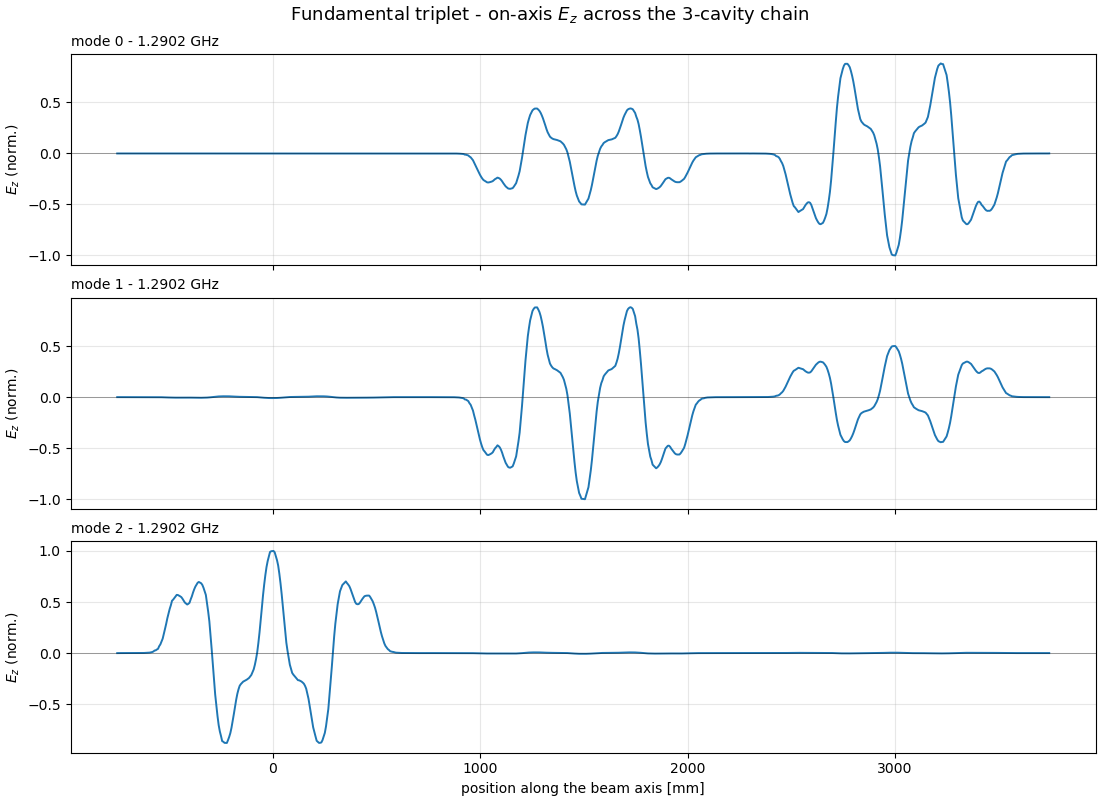

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(11, 8), sharex=True, layout='constrained')

for ax, (k, f_k) in zip(axs, fundamental):
    z, Ez, _ = concat.chain_axis_profile(mode_idx=int(k), n_points=800)
    e = np.real(Ez)
    e = e / np.nanmax(np.abs(e))                  # normalise for comparison
    ax.plot(z * 1e3, e, lw=1.4)
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_ylabel('$E_z$ (norm.)')
    ax.set_title(f'mode {int(k)} - {f_k:.4f} GHz', fontsize=10, loc='left')
    ax.grid(alpha=0.3)

axs[-1].set_xlabel('position along the beam axis [mm]')
fig.suptitle('Fundamental triplet - on-axis $E_z$ across the 3-cavity chain', fontsize=13)

The three curves span the full 4.5 m chain (three 1.5 m cavities end to end) and share a
frequency to four decimals, differing in how the field is distributed across the three cavities
-- that distribution is what distinguishes the triplet members.

!!! note "What this profile does and does not resolve"
    The curves show roughly 9-12 lobes across the whole chain, not the 27 that fully resolved
    nine-cell cavities would give. That is the reduced model doing its job: POD keeps about 46
    DOFs per cavity, chosen to reproduce the **port-to-port response** over $1.0-1.8$ GHz, so
    the on-axis profile captures the accelerating-field envelope along the chain rather than
    every individual cell. Resolving each cell needs a richer basis -- more snapshots, a tighter
    `tol`, or a band concentrated on the passband.

## Summary

| Stage | Cost |
|-------|------|
| Full-order solve, **one** cavity | minutes |
| POD reduction | seconds |
| Concatenation of 3 reduced cavities | milliseconds |
| 800-point sweep of the whole chain | milliseconds |

The full-order cost is paid once and does not grow with chain length: a 3-cavity chain and a
30-cavity chain reuse the same reduced cavity, and only the coupled system changes size.

**See also:** [Repeat a section](multi_part/repeated_sections.ipynb) runs the same pipeline
on a small rectangular waveguide, where the whole notebook takes about a minute.